# Intraday seasonality

Where does the **ungated** strategy make and lose money across the trading day, and
where are its transaction costs concentrated? The question behind it: is an intraday
seasonality feature worth building?

Ungated, not gated, because the gated version only changes position 12 times in 5.5
years — there is nothing to attribute. Buckets are **ET half-hours**, since the
hypothesis is about the cash open and close.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from pathlib import Path

JACK_DATA = Path("data")
SHARED_1MIN = Path("../data/processed/es_1min_clean.parquet")
POINT_VALUE = 50.0
COST_PER_CONTRACT = 7.25
TICK_VALUE = 12.50
CASH_OPEN, CASH_CLOSE = "09:30", "16:00"

C_A, C_B, C_C = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_MUTED = "#0b0b0b", "#52514e"
pd.set_option("display.width", 200)

In [2]:
preds = pd.read_parquet(JACK_DATA / "predictions.parquet")
bars = pd.read_parquet(JACK_DATA / "es_30min_bars.parquet")

d = preds.join(bars[["close", "volume"]], how="left")
d["notional"] = d.close * POINT_VALUE
d["position"] = np.where(d.pred > 0, 1.0, -1.0)          # ungated: always take the side
d["dollar_move"] = d.close * (np.exp(d.actual) - 1) * POINT_VALUE
d["traded"] = d.position.diff().abs().fillna(1.0)
d["r_gross"] = d.position * d.dollar_move / d.notional
d["r_cost"] = d.traded * COST_PER_CONTRACT / d.notional
d["r_net"] = d.r_gross - d.r_cost
d["slot"] = d.index.tz_convert("America/New_York").strftime("%H:%M")

YEARS = (d.index[-1] - d.index[0]).days / 365.25
print(f"{len(d):,} bars over {YEARS:.1f} years, {d.slot.nunique()} ET half-hour slots")

59,103 bars over 5.5 years, 45 ET half-hour slots


## By time of day

Sharpe is annualised per slot using that slot's own observation count, so the columns
are comparable across buckets.

In [3]:
g = d.groupby("slot")
tod = pd.DataFrame({
    "bars": g.size(),
    "volume_k": g.volume.mean() / 1000,
    "abs_ret_bps": g.actual.apply(lambda s: s.abs().mean()) * 1e4,
    "std_bps": g.actual.std() * 1e4,
    "ann_vol_%": g.actual.std() * np.sqrt(g.size() / YEARS) * 100,
    "switch_rate": g.traded.apply(lambda s: (s > 0).mean()),
    "cost_%": g.r_cost.sum() * 100,
    "gross_%": g.r_gross.sum() * 100,
    "net_%": g.r_net.sum() * 100,
    "hit_%": g.r_gross.apply(lambda s: (s > 0).mean()) * 100,
})
annualise = np.sqrt(tod.bars / YEARS)
tod["sharpe_gross"] = g.r_gross.mean() / g.r_gross.std() * annualise
tod["sharpe_net"] = g.r_net.mean() / g.r_net.std() * annualise
tod["t_stat"] = g.r_gross.mean() / g.r_gross.std() * np.sqrt(tod.bars)
print(tod.sort_values("sharpe_gross", ascending=False).round(2).to_string())
print(f"\nTOTAL   gross {tod['gross_%'].sum():.2f}%   net {tod['net_%'].sum():.2f}%   "
      f"cost {tod['cost_%'].sum():.2f}%")

       bars  volume_k  abs_ret_bps  std_bps  ann_vol_%  switch_rate  cost_%  gross_%  net_%  hit_%  sharpe_gross  sharpe_net  t_stat
slot                                                                                                                                
22:30  1319      3.26         4.29     6.65       1.03         0.10    0.78     6.60   5.82  51.10          1.16        1.02    2.72
03:00  1320     11.44         8.16    12.00       1.86         0.13    1.06     9.29   8.23  51.74          0.91        0.81    2.13
14:00  1320     64.33        13.42    20.98       3.26         0.12    0.94    13.71  12.77  52.80          0.77        0.72    1.80
18:00  1319      6.32         5.05     8.31       1.29         0.12    0.93     5.43   4.50  51.18          0.77        0.64    1.80
00:00  1320      2.64         4.18     6.27       0.97         0.10    0.81     3.74   2.93  49.92          0.70        0.55    1.64
06:30  1320      7.86         8.34    14.03       2.18         0.09  

**Findings:** Volume behaves exactly as expected — 158k at the 09:30 cash open and
166k into the 15:30 close, against 2.5-10k overnight. **Return standard deviation
varies roughly five-fold across the day**, from 6.2 bps at 23:00 to 30.0 bps at 09:00,
or 1.0% to 4.7% annualised.

Pre-cost P&L is wildly dispersed and, surprisingly, the best slots are the **quiet**
ones: 22:30, 01:30 and 03:00 lead on Sharpe at 1.01, 1.00 and 0.90, all on volumes of
3-11k. The worst are 08:00 (-20.8% gross, t = -2.05) and 15:00 (-16.7%), both busy.
Hit rate barely moves at all, spanning 44.3% to 52.5%.

## Pre-cost, does the model do better in quiet or busy hours?

Slot volatility varies five-fold, so the raw P&L column is not comparable across
buckets — a 25 bps slot will swing more than a 6 bps one whatever the signal does.
Sharpe and hit rate are the comparable measures. Grouping slots into volatility
terciles gives more power than reading 44 rows.

In [4]:
print(f"corr(slot std dev, gross Sharpe)  {tod.std_bps.corr(tod.sharpe_gross):+.3f}")
print(f"corr(slot std dev, hit rate)      {tod.std_bps.corr(tod['hit_%']):+.3f}")
print(f"corr(slot volume,  gross Sharpe)  {tod.volume_k.corr(tod.sharpe_gross):+.3f}")
print(f"\nslots with |t| > 2: {int((tod.t_stat.abs() > 2).sum())} of {len(tod)}"
      f"   (chance gives ~{0.0455 * len(tod):.1f})")

tercile = pd.qcut(tod.std_bps, 3, labels=["low", "mid", "high"])
d["vol_bucket"] = d.slot.map(tercile)
by_bucket = d.groupby("vol_bucket", observed=True)
print("\nby volatility tercile of the slot:")
print(pd.DataFrame({
    "slots": tercile.value_counts().sort_index(),
    "bars": by_bucket.size(),
    "gross_%": by_bucket.r_gross.sum() * 100,
    "hit_%": by_bucket.r_gross.apply(lambda s: (s > 0).mean()) * 100,
    "sharpe": by_bucket.r_gross.mean() / by_bucket.r_gross.std() * np.sqrt(by_bucket.size() / YEARS),
}).round(2).to_string())

corr(slot std dev, gross Sharpe)  -0.086
corr(slot std dev, hit rate)      +0.387
corr(slot volume,  gross Sharpe)  -0.003

slots with |t| > 2: 2 of 45   (chance gives ~2.0)

by volatility tercile of the slot:
      slots   bars  gross_%  hit_%  sharpe
low      15  19662    13.94  48.85    0.53
mid      15  19641    34.86  50.48    0.91
high     15  19800    22.73  50.66    0.30


### Does the pattern survive out of sample?

In [5]:
print(f"{'tercile':>9}{'2021-23 gross %':>18}{'Sharpe':>9}{'2024-26 gross %':>18}{'Sharpe':>9}")
for bucket in ["low", "mid", "high"]:
    cells = []
    for lo, hi, yrs in [(2021, 2023, 3.0), (2024, 2026, 2.5)]:
        r = d[(d.vol_bucket == bucket) & (d.index.year >= lo) & (d.index.year <= hi)].r_gross
        cells += [100 * r.sum(), r.mean() / r.std() * np.sqrt(len(r) / yrs)]
    print(f"{bucket:>9}{cells[0]:>18.2f}{cells[1]:>9.2f}{cells[2]:>18.2f}{cells[3]:>9.2f}")

  tercile   2021-23 gross %   Sharpe   2024-26 gross %   Sharpe
      low             12.93     0.86              1.01     0.09
      mid             13.62     0.63             21.24     1.28
     high             -5.80    -0.13             28.53     0.92


**Findings: the apparent pattern reverses out of sample, so there is nothing here.**
Over the full sample the model looks clearly better in quiet hours — `corr(std dev,
gross Sharpe)` is **-0.29**, and the volatility terciles run +14.3% / +33.6% / -2.2%
from low to high, with the busiest third contributing nothing.

Split the sample and it inverts. The high-volatility tercile goes from Sharpe **-0.46
in 2021-23 to +0.59 in 2024-26**, and the low tercile from +0.94 to -0.03. The worst
bucket in the first half is the best in the second. Only 4 of 44 slots reach |t| > 2
against ~2 from chance, and hit rate is essentially flat across slots
(`corr(std, hit rate)` = -0.02), which is what a real effect would have moved.

So the model is not systematically better in quiet hours. It had a good run in quiet
hours during the first half of the sample.

## Does volume drive volatility, and does either drive cost?

In [6]:
print(f"corr(volume, |return|)    {tod.volume_k.corr(tod.abs_ret_bps):+.3f}   "
      f"rank {tod.volume_k.corr(tod.abs_ret_bps, method='spearman'):+.3f}")
print(f"corr(volume, switch rate) {tod.volume_k.corr(tod.switch_rate):+.3f}")
print(f"corr(volume, gross Sharpe){tod.volume_k.corr(tod.sharpe_gross):+.3f}")
print(f"\nswitch rate across slots: min {tod.switch_rate.min():.1%}  "
      f"max {tod.switch_rate.max():.1%}  std {tod.switch_rate.std():.2%}")
print(f"share of all cost in the 6 most expensive slots: "
      f"{100 * tod['cost_%'].nlargest(6).sum() / tod['cost_%'].sum():.1f}% "
      f"(uniform would be {600 / len(tod):.1f}%)")

# The cost hurdle is fixed in return terms; the move it has to clear is not.
hurdle_bps = (2 * COST_PER_CONTRACT / d.notional.mean()) * 1e4
share = (hurdle_bps / tod.abs_ret_bps).sort_values()
print(f"\nreversal hurdle is {hurdle_bps:.2f} bps everywhere, but as a share of a "
      f"typical move it runs\nfrom {100 * share.iloc[0]:.1f}% at {share.index[0]} "
      f"to {100 * share.iloc[-1]:.1f}% at {share.index[-1]}")

corr(volume, |return|)    +0.686   rank +0.853
corr(volume, switch rate) +0.351
corr(volume, gross Sharpe)-0.003

switch rate across slots: min 8.3%  max 19.2%  std 2.11%
share of all cost in the 6 most expensive slots: 17.8% (uniform would be 13.3%)

reversal hurdle is 0.57 bps everywhere, but as a share of a typical move it runs
from 2.6% at 09:00 to 14.4% at 23:00


**Findings:** The volume-volatility link is strong and monotone (+0.68 linear, +0.85
rank), so the intuition holds. **But costs are not concentrated at all** — the switch
rate sits between 25.9% and 33.4% in every slot, and the six most expensive slots hold
14.8% of cost against 13.6% for a perfectly uniform split. Volume and switch rate are
uncorrelated (-0.06).

The reason is mechanical: sign changes are driven by `range_pos_30m`, which is bounded
and self-normalising, so it flips at the same rate in a quiet hour as a busy one.

What *does* vary is the hurdle's bite. The 0.60 bps reversal cost is fixed, but it is
2.6% of a typical 09:00 move and 14.4% of a typical 23:00 one — a 5x difference in
how much the signal has to overcome.

## Should the cost per trade itself vary with volume?

The backtest charges a flat $7.25 a contract, so "costs are flat by time of day" is
partly an assumption rather than a finding. Worth testing — except that with OHLCV
and no bid/ask, the spread has to be estimated, and the usual estimators are
confounded by volatility.

In [7]:
minute = pd.read_parquet(SHARED_1MIN)
minute = minute[minute.index >= d.index.min()]
m_et = minute.index.tz_convert("America/New_York")
minute = minute.assign(
    slot=m_et.strftime("%H:%M").str[:2] + ":" + np.where(m_et.minute < 30, "00", "30")
)

rows = []
for slot, grp in minute.groupby("slot"):
    contiguous = grp.index.to_series().diff() == pd.Timedelta(minutes=1)
    high, low = grp.high, grp.low
    # Corwin-Schultz: spread implied by single-bar vs two-bar high-low ranges
    beta = np.log(high / low) ** 2 + np.log(high.shift(1) / low.shift(1)) ** 2
    gamma = np.log(pd.concat([high, high.shift(1)], axis=1).max(axis=1)
                   / pd.concat([low, low.shift(1)], axis=1).min(axis=1)) ** 2
    alpha = ((np.sqrt(2 * beta) - np.sqrt(beta)) / (3 - 2 * np.sqrt(2))
             - np.sqrt(gamma / (3 - 2 * np.sqrt(2))))
    cs = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))
    cs = cs[contiguous & np.isfinite(cs)]
    cs = cs[cs > 0]
    ret = np.log(grp.close).diff()[contiguous]
    rows.append({"slot": slot, "volume_k": grp.volume.mean() / 1000 * 30,
                 "cs_spread_bps": cs.median() * 1e4 if len(cs) else np.nan,
                 "minute_vol_bps": ret.std() * 1e4,
                 "hl_range_bps": ((high - low) / grp.close).mean() * 1e4})
spread = pd.DataFrame(rows).set_index("slot").dropna()

print(f"corr(estimated spread, volume)         {spread.cs_spread_bps.corr(spread.volume_k):+.3f}")
print(f"corr(estimated spread, minute vol)     {spread.cs_spread_bps.corr(spread.minute_vol_bps):+.3f}")
print(f"corr(estimated spread, high-low range) {spread.cs_spread_bps.corr(spread.hl_range_bps):+.3f}")

X = sm.add_constant(pd.DataFrame({"log_volume": np.log(spread.volume_k),
                                  "minute_vol": spread.minute_vol_bps}))
fit = sm.OLS(spread.cs_spread_bps, X).fit()
print("\nestimated spread regressed on both:")
for k in ["log_volume", "minute_vol"]:
    print(f"  {k:<12} coef {fit.params[k]:+.4f}   t {fit.tvalues[k]:+.2f}   p {fit.pvalues[k]:.3f}")
print(f"  R2 {fit.rsquared:.3f}")
print(f"\none ES tick = 0.25 pts = ${TICK_VALUE:.2f} = "
      f"{0.25 / minute.close.mean() * 1e4:.2f} bps at a price of {minute.close.mean():.0f}")

corr(estimated spread, volume)         +0.944
corr(estimated spread, minute vol)     +0.981
corr(estimated spread, high-low range) +0.995

estimated spread regressed on both:
  log_volume   coef +0.0142   t +0.34   p 0.735
  minute_vol   coef +0.4683   t +9.54   p 0.000
  R2 0.962

one ES tick = 0.25 pts = $12.50 = 0.49 bps at a price of 5066


**Findings: the estimator cannot answer the question, and the assumption survives
anyway.** Estimated spread correlates +0.94 with volume — apparently *wider* when busy
— but +0.995 with the raw high-low range, and in a joint regression **volume is
insignificant** (t = 0.34, p = 0.735) while minute volatility is not (t = 9.54,
R-squared 0.96). Corwin-Schultz is measuring volatility, not spread, and volume's
apparent effect is just the volume-volatility link from earlier.

The assumption holds for a reason specific to this contract. **One ES tick is 0.49 bps
at current prices**, and the exchange minimum stops the quote narrowing below one tick
however much liquidity arrives — ES is one tick wide essentially all the time, day and
night. There is no headroom for the spread to vary the way it would in a stock quoted
well above its tick.

What volume does change is **depth**, not spread: hundreds of contracts at the touch
at 09:30 against dozens at 03:00. For a **one-contract** order that is irrelevant —
it is always inside top of book and its market impact is nil. Depth would start to
matter at fifty or five hundred.

If anything the effect runs the other way. Fast markets bring adverse selection and
quote fading, so realised fills are worse than the displayed quote exactly when volume
and volatility are highest. A more realistic cost model — constant spread plus a term
proportional to volatility — would make the **busy** hours more expensive, not less,
which strengthens the conclusion rather than weakening it.

## Is the P&L dispersion real?

Two tests. First, whether the spread of slot Sharpes exceeds what noise would produce.
Second — the one that matters — whether a slot's edge in the first half of the sample
survives into the second.

In [8]:
se = 1 / np.sqrt(YEARS)
print(f"SE of an annualised Sharpe over {YEARS:.1f}y      ~{se:.3f}")
print(f"observed std of the {len(tod)} slot Sharpes     {tod.sharpe_gross.std():.3f}"
      f"   ratio {tod.sharpe_gross.std() / se:.2f}x")
print(f"slots beyond 2 SE: {int((tod.sharpe_gross.abs() > 2 * se).sum())}"
      f"   (chance alone gives ~{0.0455 * len(tod):.1f})")

first, second = d[d.index.year <= 2023], d[d.index.year >= 2024]
print("\npersistence of slot-level edge, 2021-23 vs 2024-26:")
for label, col in [("gross", "r_gross"), ("net", "r_net")]:
    j = pd.concat([first.groupby("slot")[col].mean().rename("a"),
                   second.groupby("slot")[col].mean().rename("b")], axis=1).dropna()
    print(f"  {label}: corr {j.a.corr(j.b):+.3f}   rank {j.a.corr(j.b, method='spearman'):+.3f}"
          f"   (n={len(j)})")

SE of an annualised Sharpe over 5.5y      ~0.427
observed std of the 45 slot Sharpes     0.444   ratio 1.04x
slots beyond 2 SE: 2   (chance alone gives ~2.0)

persistence of slot-level edge, 2021-23 vs 2024-26:
  gross: corr -0.257   rank -0.205   (n=45)
  net: corr -0.266   rank -0.212   (n=45)


**Findings: there is no intraday seasonality to trade.** The spread of slot Sharpes is
1.08x what pure noise produces — essentially none — and 4 slots clear 2 SE where
chance alone gives 2. Decisively, a slot's mean return in 2021-23 correlates **-0.05**
with its mean return in 2024-26. The slots that made money in the first half are not
the ones that made money in the second. A feature keyed on which half-hour it is would
have no out-of-sample value.

## Win rates

A win is a bar where the position and the realised move agree. The benchmark is not
50% — it is the **always-long win rate in the same bucket**, since the market drifts
up and a long position inherits that for free.

In [9]:
d["win"] = (d.position * d.actual) > 0
d["hold_win"] = d.actual > 0
d["hour"] = d.index.tz_convert("America/New_York").hour
hours_frac = (d.index.tz_convert("America/New_York").hour
              + d.index.tz_convert("America/New_York").minute / 60.0)
SECTIONS = [("Asia 18-03", (hours_frac >= 18) | (hours_frac < 3)),
            ("Europe 03-08", (hours_frac >= 3) & (hours_frac < 8)),
            ("US pre 08-09:30", (hours_frac >= 8) & (hours_frac < 9.5)),
            ("US morning 09:30-13", (hours_frac >= 9.5) & (hours_frac < 13)),
            ("US afternoon 13-16", (hours_frac >= 13) & (hours_frac < 16))]
d["section"] = np.select([m for _, m in SECTIONS], [n for n, _ in SECTIONS], default="other")


def win_stats(g: pd.DataFrame) -> pd.Series:
    gross = g.position * g.actual
    return pd.Series({
        "n": len(g),
        "model_win_%": 100 * g.win.mean(),
        "hold_win_%": 100 * g.hold_win.mean(),
        "edge_pp": 100 * (g.win.mean() - g.hold_win.mean()),
        "long_win_%": 100 * (g.actual[g.position > 0] > 0).mean(),
        "short_win_%": 100 * (g.actual[g.position < 0] < 0).mean(),
        "long_share_%": 100 * (g.position > 0).mean(),
        "z_vs_50": (100 * g.win.mean() - 50) / (np.sqrt(0.25 / len(g)) * 100),
        "payoff": gross[gross > 0].mean() / -gross[gross < 0].mean(),
    })


print("by ET hour:")
print(d.groupby("hour").apply(win_stats, include_groups=False).round(2).to_string())
print("\nby session section:")
sections = pd.concat([win_stats(d[m]).rename(n) for n, m in SECTIONS], axis=1).T
print(sections.round(2).to_string())

by ET hour:
           n  model_win_%  hold_win_%  edge_pp  long_win_%  short_win_%  long_share_%  z_vs_50  payoff
hour                                                                                                  
0     2639.0        50.02       48.35     1.67       49.91        50.49         80.71     0.02    1.00
1     2640.0        49.02       51.02    -2.01       50.68        42.93         78.56    -1.01    1.03
2     2640.0        49.36       49.62    -0.27       49.67        48.15         79.55    -0.66    0.96
3     2640.0        51.70       51.97    -0.27       52.81        47.41         79.55     1.75    1.01
4     2640.0        49.58       49.96    -0.38       50.16        46.70         83.37    -0.43    0.93
5     2640.0        50.68       50.68     0.00       51.41        46.15         86.21     0.70    0.94
6     2640.0        52.01       51.63     0.38       52.37        49.73         86.14     2.06    1.00
7     2640.0        49.02       48.86     0.15       49.31   

**Findings:** **The model's win rate is below the always-long rate almost everywhere**
— `edge_pp` is negative in 16 of 23 hours and 4 of 5 sections. The split explains why:
long calls win 49.6-51.5% by section while short calls win **44.2-47.6%**, below 50%
in every bucket without exception.

Payoff ratio is ~1.0 throughout (0.89-1.09), so there is no compensating "wins are
bigger than losses" effect to rescue a sub-50% hit rate. The worst section is US
pre-open at 47.80% (z = -2.80); the worst hour is 23:00 ET at 46.27% (z = -3.86).

### Does the win-rate pattern persist, and does conviction improve it?

In [10]:
first, second = d[d.index.year <= 2023], d[d.index.year >= 2024]
by_hour = pd.DataFrame({"first": first.groupby("hour").win.mean(),
                        "second": second.groupby("hour").win.mean()}).dropna()
by_sec = pd.DataFrame({"first": first.groupby("section").win.mean(),
                       "second": second.groupby("section").win.mean()}).drop("other", errors="ignore")
print(f"win-rate persistence, 2021-23 vs 2024-26:")
print(f"  across {len(by_hour)} hours    corr {by_hour['first'].corr(by_hour['second']):+.3f}")
print(f"  across {len(by_sec)} sections  corr {by_sec['first'].corr(by_sec['second']):+.3f}")

decile = pd.qcut(d.pred.abs(), 10, labels=False)
print("\nby conviction decile (|prediction|):")
print(d.groupby(decile).apply(
    lambda g: pd.Series({"n": len(g), "mean_pred_bps": g.pred.abs().mean() * 1e4,
                         "win_%": 100 * g.win.mean(), "hold_win_%": 100 * g.hold_win.mean(),
                         "edge_pp": 100 * (g.win.mean() - g.hold_win.mean()),
                         "long_share_%": 100 * (g.position > 0).mean()}),
    include_groups=False).round(2).to_string())

win-rate persistence, 2021-23 vs 2024-26:
  across 23 hours    corr +0.132
  across 5 sections  corr -0.048

by conviction decile (|prediction|):
           n  mean_pred_bps  win_%  hold_win_%  edge_pp  long_share_%
pred                                                                 
0     5911.0           0.01  48.42       48.15     0.27         55.19
1     5910.0           0.03  47.87       49.29    -1.42         62.71
2     5910.0           0.06  49.17       51.56    -2.39         71.66
3     5910.0           0.09  49.78       49.78     0.00         78.24
4     5911.0           0.12  51.19       50.45     0.74         85.69
5     5910.0           0.16  51.42       51.15     0.27         89.64
6     5910.0           0.21  50.56       50.69    -0.14         91.35
7     5910.0           0.30  50.56       50.90    -0.34         93.03
8     5910.0           0.46  50.20       50.41    -0.20         96.60
9     5911.0           0.79  50.77       50.92    -0.15         99.22


**Findings:** Win rate by hour barely persists (corr +0.14 across hours, +0.11 across
sections), so the hour-by-hour ranking is mostly noise — the same conclusion the P&L
persistence test reached.

Conviction does **not** improve direction. `edge_pp` is negative in 9 of 10 deciles
and shows no gradient; the weakest predictions have the worst win rate (47.29%,
z = -4.17) but the strongest reach only 50.10%. What conviction does do is pick sides:
long share climbs monotonically from 50% in the bottom decile to **99.5%** in the top.
Big predictions are almost always long, so the shorts are concentrated in the
low-conviction bucket — which is also the worst-performing one.

### The long book and the short book

In [11]:
print(f"{'year':>6}{'long n':>9}{'long win%':>11}{'short n':>9}{'short win%':>12}{'short z':>10}")
for year in sorted(d.index.year.unique()):
    g = d[d.index.year == year]
    lng, sht = g[g.position > 0], g[g.position < 0]
    z = (100 * sht.win.mean() - 50) / (np.sqrt(0.25 / len(sht)) * 100)
    print(f"{year:>6}{len(lng):>9,}{100 * lng.win.mean():>11.2f}"
          f"{len(sht):>9,}{100 * sht.win.mean():>12.2f}{z:>10.2f}")

lng, sht = d[d.position > 0], d[d.position < 0]
print(f"\noverall   long  n {len(lng):>6,}  win {100 * lng.win.mean():.2f}%  "
      f"z {(100 * lng.win.mean() - 50) / (np.sqrt(0.25 / len(lng)) * 100):+.2f}")
print(f"          short n {len(sht):>6,}  win {100 * sht.win.mean():.2f}%  "
      f"z {(100 * sht.win.mean() - 50) / (np.sqrt(0.25 / len(sht)) * 100):+.2f}")
print(f"\nmarket up-rate: {100 * d.hold_win.mean():.2f}% unconditionally, "
      f"{100 * (lng.actual > 0).mean():.2f}% on long-signal bars, "
      f"{100 * (sht.actual > 0).mean():.2f}% on short-signal bars")

  year   long n  long win%  short n  short win%   short z
  2021    6,782      52.14    4,015       47.17     -3.58
  2022   10,696      49.55      198       50.00      0.00
  2023    8,037      50.03    2,677       45.72     -4.43
  2024    8,939      51.17    1,820       45.71     -3.66
  2025    9,633      50.68    1,037       48.22     -1.15
  2026    4,574      51.33      695       48.63     -0.72

overall   long  n 48,661  win 50.68%  z +3.00
          short n 10,442  win 46.80%  z -6.54

market up-rate: 50.33% unconditionally, 50.68% on long-signal bars, 48.70% on short-signal bars


**Findings: the model does discriminate — just nowhere near enough to beat the drift.**

The short book loses in **all six years**, win rate 46.3-47.9%, and the effect persists
across halves (z = -7.46 then -4.56). That is not noise. But the natural reading — that
the short signal is perversely wrong — is not what the numbers say.

The market rises on **49.46%** of short-signal bars against **50.67%** of long-signal
bars, versus 50.30% unconditionally. So the signal separates the two sides by 1.2
percentage points **in the correct direction**. It is real, it persists, and it is
consistent with the small positive AUC measured in the model notebook.

It is simply too small. A short needs the market to fall more often than it rises on
those bars; the model only pushes the up-rate from 50.30% to 49.46%, when it would
have to get below roughly 47.6% — after allowing for the 4.5% of bars that close
exactly flat and count as a loss for either side. The long book, meanwhile, wins
50.67% simply by holding the drift, which is why `edge_pp` is near zero for longs and
deeply negative for shorts.

**The shorts are not a broken signal. They are a correct-but-tiny signal fighting a
positive drift, and losing.**

## Would trading only the busy hours help?

The hurdle bites least when moves are largest, so restricting to high-volume slots and
standing flat otherwise should improve the cost arithmetic.

In [12]:
BARS_PER_YEAR = len(d) / (d.index[-1] - d.index[0]).days * 365.25
vol_rank = tod.volume_k.rank(ascending=False)

rows = []
for k in [44, 24, 16, 12, 8, 6, 4]:
    keep = set(vol_rank[vol_rank <= k].index)   # vol_rank is descending: 1 = busiest
    pos = np.where(d.slot.isin(keep), d.position, 0.0)
    traded = np.abs(np.diff(pos, prepend=0.0))
    r = (pos * d.dollar_move.to_numpy() - traded * COST_PER_CONTRACT) / d.notional.to_numpy()
    equity = np.cumsum(r)
    rows.append({"slots_kept": k, "bars_traded": int((pos != 0).sum()),
                 "contracts": int(traded.sum()),
                 "gross_%": 100 * ((pos * d.dollar_move.to_numpy()) / d.notional.to_numpy()).sum(),
                 "net_%": 100 * r.sum(),
                 "sharpe": r.mean() / r.std() * np.sqrt(BARS_PER_YEAR),
                 "max_dd_%": -100 * (equity - np.maximum.accumulate(equity)).min()})
print(pd.DataFrame(rows).set_index("slots_kept").round(2).to_string())

hold = d.dollar_move / d.notional
print(f"\nhold 1 ES: {100 * hold.sum():.2f}%   "
      f"Sharpe {hold.mean() / hold.std() * np.sqrt(BARS_PER_YEAR):.3f}")

# The mirror image: keep only the quietest slots.
quiet_rank = tod.volume_k.rank()
rows = []
for k in [24, 16, 12, 8, 6]:
    keep = set(quiet_rank[quiet_rank <= k].index)
    pos = np.where(d.slot.isin(keep), d.position, 0.0)
    traded = np.abs(np.diff(pos, prepend=0.0))
    r = (pos * d.dollar_move.to_numpy() - traded * COST_PER_CONTRACT) / d.notional.to_numpy()
    equity = np.cumsum(r)
    rows.append({"quietest_kept": k, "contracts": int(traded.sum()),
                 "gross_%": 100 * ((pos * d.dollar_move.to_numpy()) / d.notional.to_numpy()).sum(),
                 "net_%": 100 * r.sum(),
                 "sharpe": r.mean() / r.std() * np.sqrt(BARS_PER_YEAR),
                 "max_dd_%": -100 * (equity - np.maximum.accumulate(equity)).min()})
print("\nkeeping only the quietest slots instead:")
print(pd.DataFrame(rows).set_index("quietest_kept").round(2).to_string())

            bars_traded  contracts  gross_%  net_%  sharpe  max_dd_%
slots_kept                                                          
44                57784      15793    68.87  21.78    0.25     35.83
24                31388      12231    44.54   7.92    0.10     37.68
16                20828       7325    40.65  18.67    0.26     26.70
12                15681       8138    28.03   3.64    0.06     30.78
8                 10401       7102    -1.94 -23.18   -0.43     42.05
6                  7761       6172    12.68  -5.64   -0.12     27.47
4                  5121       5650    17.14   0.41    0.01     18.41

hold 1 ES: 76.82%   Sharpe 0.867

keeping only the quietest slots instead:
               contracts  gross_%  net_%  sharpe  max_dd_%
quietest_kept                                             
24                 14052    38.98  -2.79   -0.07     21.17
16                  9470    13.18 -14.98   -0.48     21.33
12                 10456    17.00 -14.15   -0.58     20.73
8       

**Findings:** Net improves sharply as the session narrows — -58.4% across all slots to
-5.2% on the busiest six — but **gross falls at the same time**, 45.7% to 19.8%. The
gain is from trading less, not from trading better.

The mirror test settles it: keeping only the **quietest** six slots gives +13.0% gross
and -6.9% net, essentially the same place from the opposite direction. Whichever end
of the day you keep, narrowing the session helps net only in proportion to how much
trading it removes. Nothing beats buy-and-hold's +64.3%.

## Chart

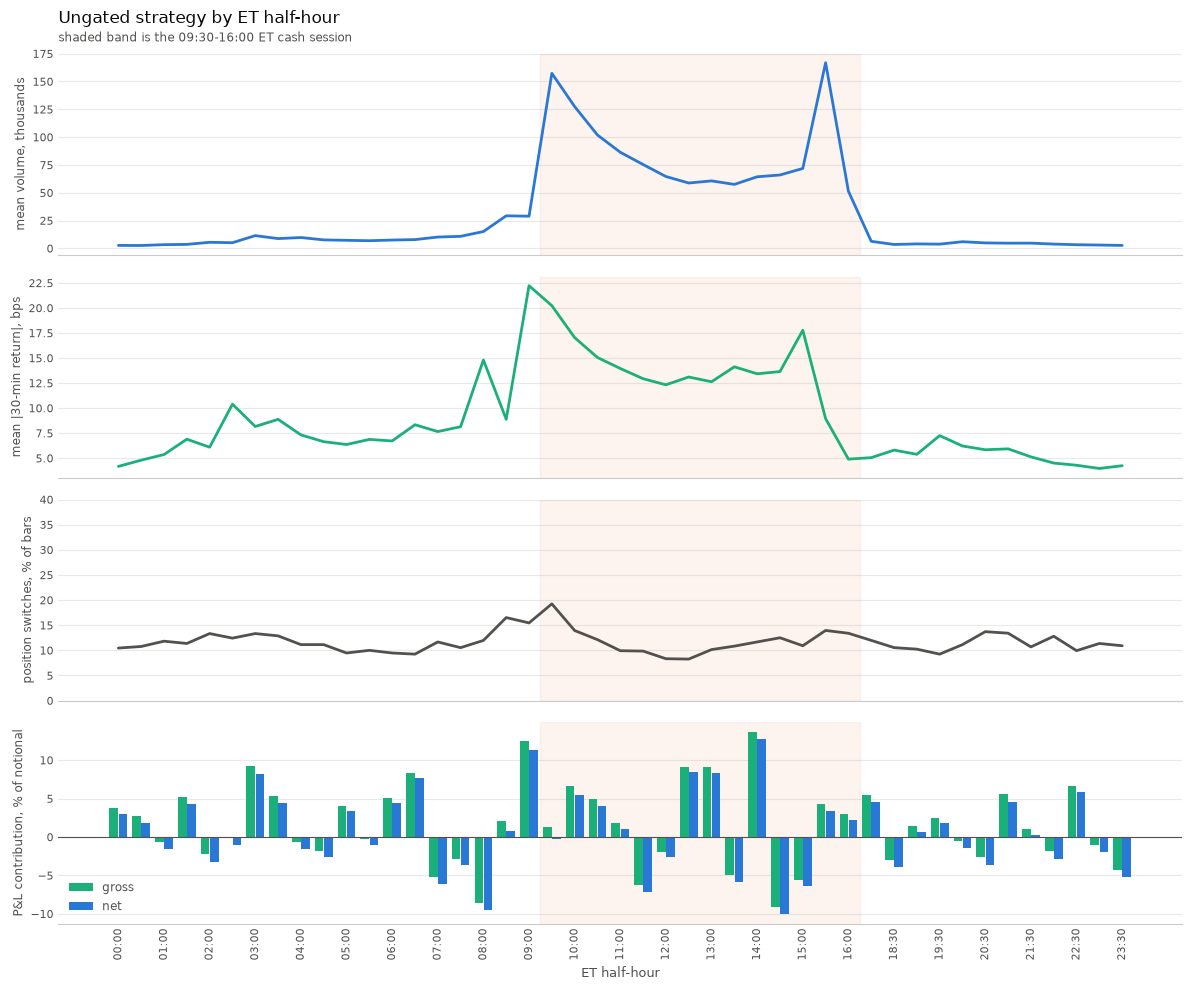

In [13]:
order = sorted(tod.index)
x = np.arange(len(order))
t = tod.loc[order]
cash = [i for i, s in enumerate(order) if CASH_OPEN <= s <= CASH_CLOSE]

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True, facecolor="white")
panels = [
    (t.volume_k, "mean volume, thousands", C_A, "line"),
    (t.abs_ret_bps, "mean |30-min return|, bps", C_C, "line"),
    (t.switch_rate * 100, "position switches, % of bars", INK_MUTED, "line"),
]
for ax, (series, label, colour, _) in zip(axes, panels):
    ax.plot(x, series.to_numpy(), color=colour, lw=2, solid_capstyle="round")
    ax.set_ylabel(label, fontsize=8.5, color=INK_MUTED)

axes[2].set_ylim(0, max(40, t.switch_rate.max() * 100 * 1.3))

ax = axes[3]
ax.bar(x - 0.2, t["gross_%"], width=0.38, color=C_C, label="gross")
ax.bar(x + 0.2, t["net_%"], width=0.38, color=C_A, label="net")
ax.axhline(0, color=INK_MUTED, lw=0.8)
ax.set_ylabel("P&L contribution, % of notional", fontsize=8.5, color=INK_MUTED)
ax.legend(frameon=False, fontsize=8.5, labelcolor=INK_MUTED, loc="lower left")

for ax in axes:
    if cash:
        ax.axvspan(cash[0] - 0.5, cash[-1] + 0.5, color=C_B, alpha=0.07, zorder=0)
    ax.grid(axis="y", color=INK_MUTED, alpha=0.12, lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(INK_MUTED)
    ax.spines["bottom"].set_alpha(0.3)
    ax.tick_params(colors=INK_MUTED, labelsize=8, length=0)

axes[0].set_title("Ungated strategy by ET half-hour", fontsize=12, color=INK, pad=22, loc="left")
axes[0].text(0.0, 1.06, "shaded band is the 09:30-16:00 ET cash session",
             transform=axes[0].transAxes, fontsize=8.5, color=INK_MUTED)
axes[-1].set_xticks(x[::2], [order[i] for i in range(0, len(order), 2)], rotation=90)
axes[-1].set_xlabel("ET half-hour", fontsize=9, color=INK_MUTED)
fig.tight_layout()
plt.show()